# Download and visualize ECMWF subseasonal forecast
If you do not have an ECMWF account, please make one here: https://accounts.ecmwf.int/auth/realms/ecmwf/login-actions/registration?client_id=cms-www&tab_id=Y_zocKf4JYs

Then head to this link to get the key that is necessary for the download: https://api.ecmwf.int/v1/key/

Make sure to have a working environment, see requirements .tx for necessary packages

Developed by Alexander Jong, feel free to email alec.jong@live.nl if you have any questions or suggestions.

### Define area of interest, import the necessary packages & functions

In [1]:
import sys
from pathlib import Path

#add so it can access functions and m-climate in parent folder
sys.path.append(str(Path.cwd().parent))

import get_ECMWF_functions as gef
import importlib
importlib.reload(gef)

from IPython.display import display
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

#m-climate region
lat1=23
lat2=-37
lon1=-20
lon2=59

gef.lat1=lat1
gef.lat2=lat2
gef.lon1=lon1
gef.lon2=lon2

## This is where you tell the ECWMF server who you are, so add your key and email to the api_config dictionary

In [25]:
# Define your API key content
api_config = {
    "url": "https://api.ecmwf.int/v1",
    "key": "f7cf0b931df86368ba8a27efce865439",  # Replace with your actual API key
    "email": "uruja@student.kit.edu"   # Replace with your email
}

gef.link_ECMWF_key(api_config)

API key file saved at: C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\Notebook\ecmwf_api_key.json
ECMWF_API_RC_FILE is set to: C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\Notebook\ecmwf_api_key.json


## Run the cell bellow to get the selection buttons.
Here you can select the start date of the forcast, which variables you want, which ensemble members you want (or ensemble mean) and how far into the future you want to get the forcast

In [3]:
from forecast_ui import build_forecast_ui

gui, ui_layout = build_forecast_ui()
display(ui_layout)

## After having selected what you want, define a filename and run the cell to donwload

In [6]:
filename='forecast'
gef.get_ECMWF(gui,filename)

🎉 All requested data has been downloaded


### Open all files and agregate them to daily and weekly data for the chosen variables
enter the name of the file you want to open, this can also be a previously dowloaded file

In [7]:
filename='forecast'

daily_all_vars,weekly_all_vars,hourly_ds,temp_ds=gef.open_allfiles_and_compute_weekly(filename)

🎉 All files opened and Agregated


### Alternatively you can open the data from the github 

In [2]:
weekly_all_vars=xr.open_dataset('../data/2026-03-22/data_weekly.nc')

## plotting

In [66]:
import efi_sot
importlib.reload(efi_sot)


<module 'efi_sot' from 'C:\\Users\\alecj\\Bureaublad\\ECMWF-S2S4AFRICA\\efi_sot.py'>

In [87]:
import os 
country='Kenya'
date_str='2026-03-22'
data_path_pf=f"data/{date_str}/ECMWF_s2s_pf_precip_forecast_weekly-and-dekade_23N-20W-37S-59E.grib"
data_path=f"data/{date_str}/data_weekly.nc"
filelist_path = f"m-climate/*.nc"
base_path=f'plots/{country}/{date_str}'
weekly_path=f'{base_path}/weekly'

# efi,sot = efi_sot.EFI_SOT(data_path_pf, filelist_path, weekly_path)


In [150]:
import glob
def open_files(data_path,filelist_path):
        # read in data
        data = xr.open_dataset(data_path)
        #data_mclim = xr.open_mfdataset("D:/Hiwi/EFI_SOT_Kenya/m-climate/*.nc",combine="nested",concat_dim="init_time")
        data_mclim= gef.open_mclimate(weekly_all_vars,folder_path=f'{str(Path.cwd())}/m-climate/')
        
        return data, data_mclim

In [103]:
def align_dims(data, data_mclim):
        mdata = data.copy(deep=True)
        mdata["time"] = mdata["time"].expand_dims("time")

        ### bring climatology and forecast to the same dimensions

        # rename dims TODO: automatize this for lat and lon
        data_changed = mdata.rename({"latitude":"lat","longitude":"lon"})
        data_mclim_changed = data_mclim.rename({"avg_2t":"t2m","latitude":"lat","longitude":"lon"})

        # bring mclim for precip to mm
        #data_mclim_changed["tp"] = data_mclim_changed["tp"]*1000
        data_mclim_changed["tp"].attrs["units"] = "mm"

        # time
        data_changed = data_changed.sel(time=data_changed["time"].dt.month.isin(data_mclim_changed["time"].dt.month))
        data_mclim_changed = data_mclim_changed.sel(time=data_mclim_changed["time"].dt.month.isin(data_changed["time"].dt.month))

        data_f = data_changed.sel(time=data_changed["time"].dt.day.isin(data_mclim_changed["time"].dt.day))
        data_clim = data_mclim_changed.sel(time=data_mclim_changed["time"].dt.day.isin(data_changed["time"].dt.day))

        # step
        data_f = data_f.sel(step=data_f["step"].isin(data_clim["step"]))
        data_clim = data_clim.sel(step=data_clim["step"].isin(data_f["step"]))

        # lon and lat
        data_f = data_f.sel(lon=data_f["lon"].isin(data_clim["lon"])).sel(lat=data_f["lat"].isin(data_clim["lat"]))
        data_clim = data_clim.sel(lon=data_clim["lon"].isin(data_f["lon"])).sel(lat=data_clim["lat"].isin(data_f["lat"]))

        # remove accumulation for precipitation
        data_f = data_f#.diff("step")


        ### some further preparations

        # aggregate the data to weekly forecast
        #data_f_calc = data_f.coarsen(step=7, boundary="trim").mean()
        data_f_calc = data_f

        # set the step which we want to compare
        #data_f_calc = data_f_calc.isel(step=0)

        # change the entries in the mclimate quantile column to the actual quantiles (due to a data issue)
        data_clim_calc = data_clim.assign_coords(quantile=list(np.linspace(0,1,101)))

        # align the times to the same year
        data_clim_calc = data_clim_calc.assign_coords(time=data_f_calc["time"])#.drop_vars("step"))

        #data_f_calc
        data_clim_calc

        return data_f_calc, data_clim_calc

def EFI(data,data_mclim,ens_dim):
        '''
        Calculates the extreme forecast index (EFI) for a forecast with respect to the m-climate.
        
        Parameters:
            data (xr.ds): The forecast
            data_mclim (xr.ds): The m-climate
            ens_dim (str): The name of the dimension in data and data_mclim that contains the ensemble number

        Returns:
            EFI (xr.ds): The EFI for the given data and climatology
        '''
        p = np.linspace(0.01,0.99,99)

        # compute the p-th quantile of the ensemble dimension for the m-climate
        data_mclim_quantiled = data_mclim.where(~data_mclim["quantile"].isin([0,1]),drop=True)#data_mclim.quantile(p,ens_dim)
        quantile = data_mclim_quantiled["quantile"]

        # calculate Qf and compute the discretized integral w.r.t. p resp. quantile
        Qf = (data.expand_dims({"quantile": quantile}) < data_mclim_quantiled).mean(ens_dim) #(data<data_mclim_quantiled).mean(ens_dim)
        result = 2/np.pi * ((quantile - Qf) / (quantile * (1-quantile))**.5).integrate("quantile")

        return result

# SOT
def SOT(data,data_mclim,ens_dim,upper_lower=False):
    '''
    Calculates the shift of tails from data with respect to the climatology in m-clim, for the difference between .9 and .99 percentiles

    Parameters:
        data (xr.ds): The forecast
        data_mclim (xr.ds): The m-climate
        ens_dim (str): The name of the dimension in data and data_mclim that contains the ensemble number
        upper_lower (bool): True if lower SOT (for .01 vs. .1 quantiles) shall be calculated in addition to the upper SOT
        
    Returns:
        SOT (xr.ds): The SOT for the given data and climatology
    '''
    if not upper_lower:
        p = [.9,.99]

        # compute the p-th quantile of the ensemble dimension
        data_mclim_quantiled = data_mclim.where(data_mclim["quantile"].isin(p),drop=True)#data_mclim.quantile(p,ens_dim)
        data_quantiled = data.quantile(p,ens_dim)

        # for readability
        Qf_90 = data_quantiled.sel(quantile=.9)
        Qc_90 = data_mclim_quantiled.sel(quantile=.9)
        Qc_99 = data_mclim_quantiled.sel(quantile=.99)

        # compute SOT
        result = (Qf_90 - Qc_99) / (Qc_99 - Qc_90)

        return result

    else:
        raise NotImplementedError("The lower SOT is not implemented as of now.")

In [9]:
os.chdir('C:\\Users\\alecj\\Bureaublad\\ECMWF-S2S4AFRICA\\')

In [37]:
import glob
def open_files(data_path,mclim_path=f'{str(Path.cwd())}/m-climate/'):
        data = xr.open_dataset(data_path)
        data_mclim= gef.open_mclimate(weekly_all_vars,folder_path=mclim_path)        
        return data, data_mclim
    
def EFI(data_f,data_clim_calc,ens_dim,var='tp'):
    data_mclim_quantiled = data_clim_calc.where(~data_clim_calc["quantile"].isin([0,1]),drop=True)#data_mclim.quantile(p,ens_dim)
    hold=[]    
    quantile=np.linspace(0.01,0.99,99)
    for i,forecast_timestep in enumerate(data_f.step.values):
        Qf = (data_f.isel(step=i) < data_mclim_quantiled.isel(time=i)).mean(ens_dim)
        result = 2/np.pi * ((quantile - Qf) / (quantile * (1-quantile))**.5).integrate("quantile")
        hold.append(result)
        
    EFI=xr.concat(hold,dim='step')
    EFI[var].attrs=data_f[var].attrs
    EFI[var].attrs['units']=''
    EFI[var].attrs['GRIB_name']='Extreme Forecast Index'
    EFI=EFI.assign_coords(time=data_f.time)
    return(EFI)

def SOT(data,data_mclim,ens_dim,upper_lower=False,var='tp'):
    '''
    Calculates the shift of tails from data with respect to the climatology in m-clim, for the difference between .9 and .99 percentiles

    Parameters:
        data (xr.ds): The forecast
        data_mclim (xr.ds): The m-climate
        ens_dim (str): The name of the dimension in data and data_mclim that contains the ensemble number
        upper_lower (bool): True if lower SOT (for .01 vs. .1 quantiles) shall be calculated in addition to the upper SOT
        
    Returns:
        SOT (xr.ds): The SOT for the given data and climatology
    '''
    if not upper_lower:
        p = [.9,.99]
        data_mclim_quantiled = data_mclim.where(data_mclim["quantile"].isin(p),drop=True)#data_mclim.quantile(p,ens_dim)
        data_quantiled = data.quantile(p,ens_dim)

        hold=[]
        for i,forecast_timestep in enumerate(data.step.values):
            # for readability
            Qf_90 = data_quantiled.sel(quantile=.9).sel(step=forecast_timestep)
            Qc_90 = data_mclim_quantiled.sel(quantile=.9).isel(time=i)
            Qc_99 = data_mclim_quantiled.sel(quantile=.99).isel(time=i)
    
            # compute SOT
            result = (Qf_90 - Qc_99) / (Qc_99 - Qc_90)
            hold.append(result)
            
        SOT=xr.concat(hold,dim='step')
        SOT[var].attrs=data[var].attrs
        SOT[var].attrs['units']=''
        SOT[var].attrs['GRIB_name']='Shift Of Tails'
        SOT=SOT.assign_coords(time=data.time)
        return SOT

    else:
        raise NotImplementedError("The lower SOT is not implemented as of now.")

date_str='2026-03-22'
data_path=f"data/{date_str}/data_weekly.nc"

base_data,base_mdata = open_files(data_path)
data_clim_calc = base_mdata.assign_coords(quantile=list(np.linspace(0,1,101)))

efi=EFI(base_data,data_clim_calc,'number')
sot = SOT(base_data,data_clim_calc,"number")

Model climatology starting on: 2025-03-21


C:\Users\alecj\AppData\Local\Temp\ipykernel_27364\3694598738.py:16: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  EFI=xr.concat(hold,dim='step')
C:\Users\alecj\AppData\Local\Temp\ipykernel_27364\3694598738.py:52: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  SOT=xr.concat(hold,dim='step')


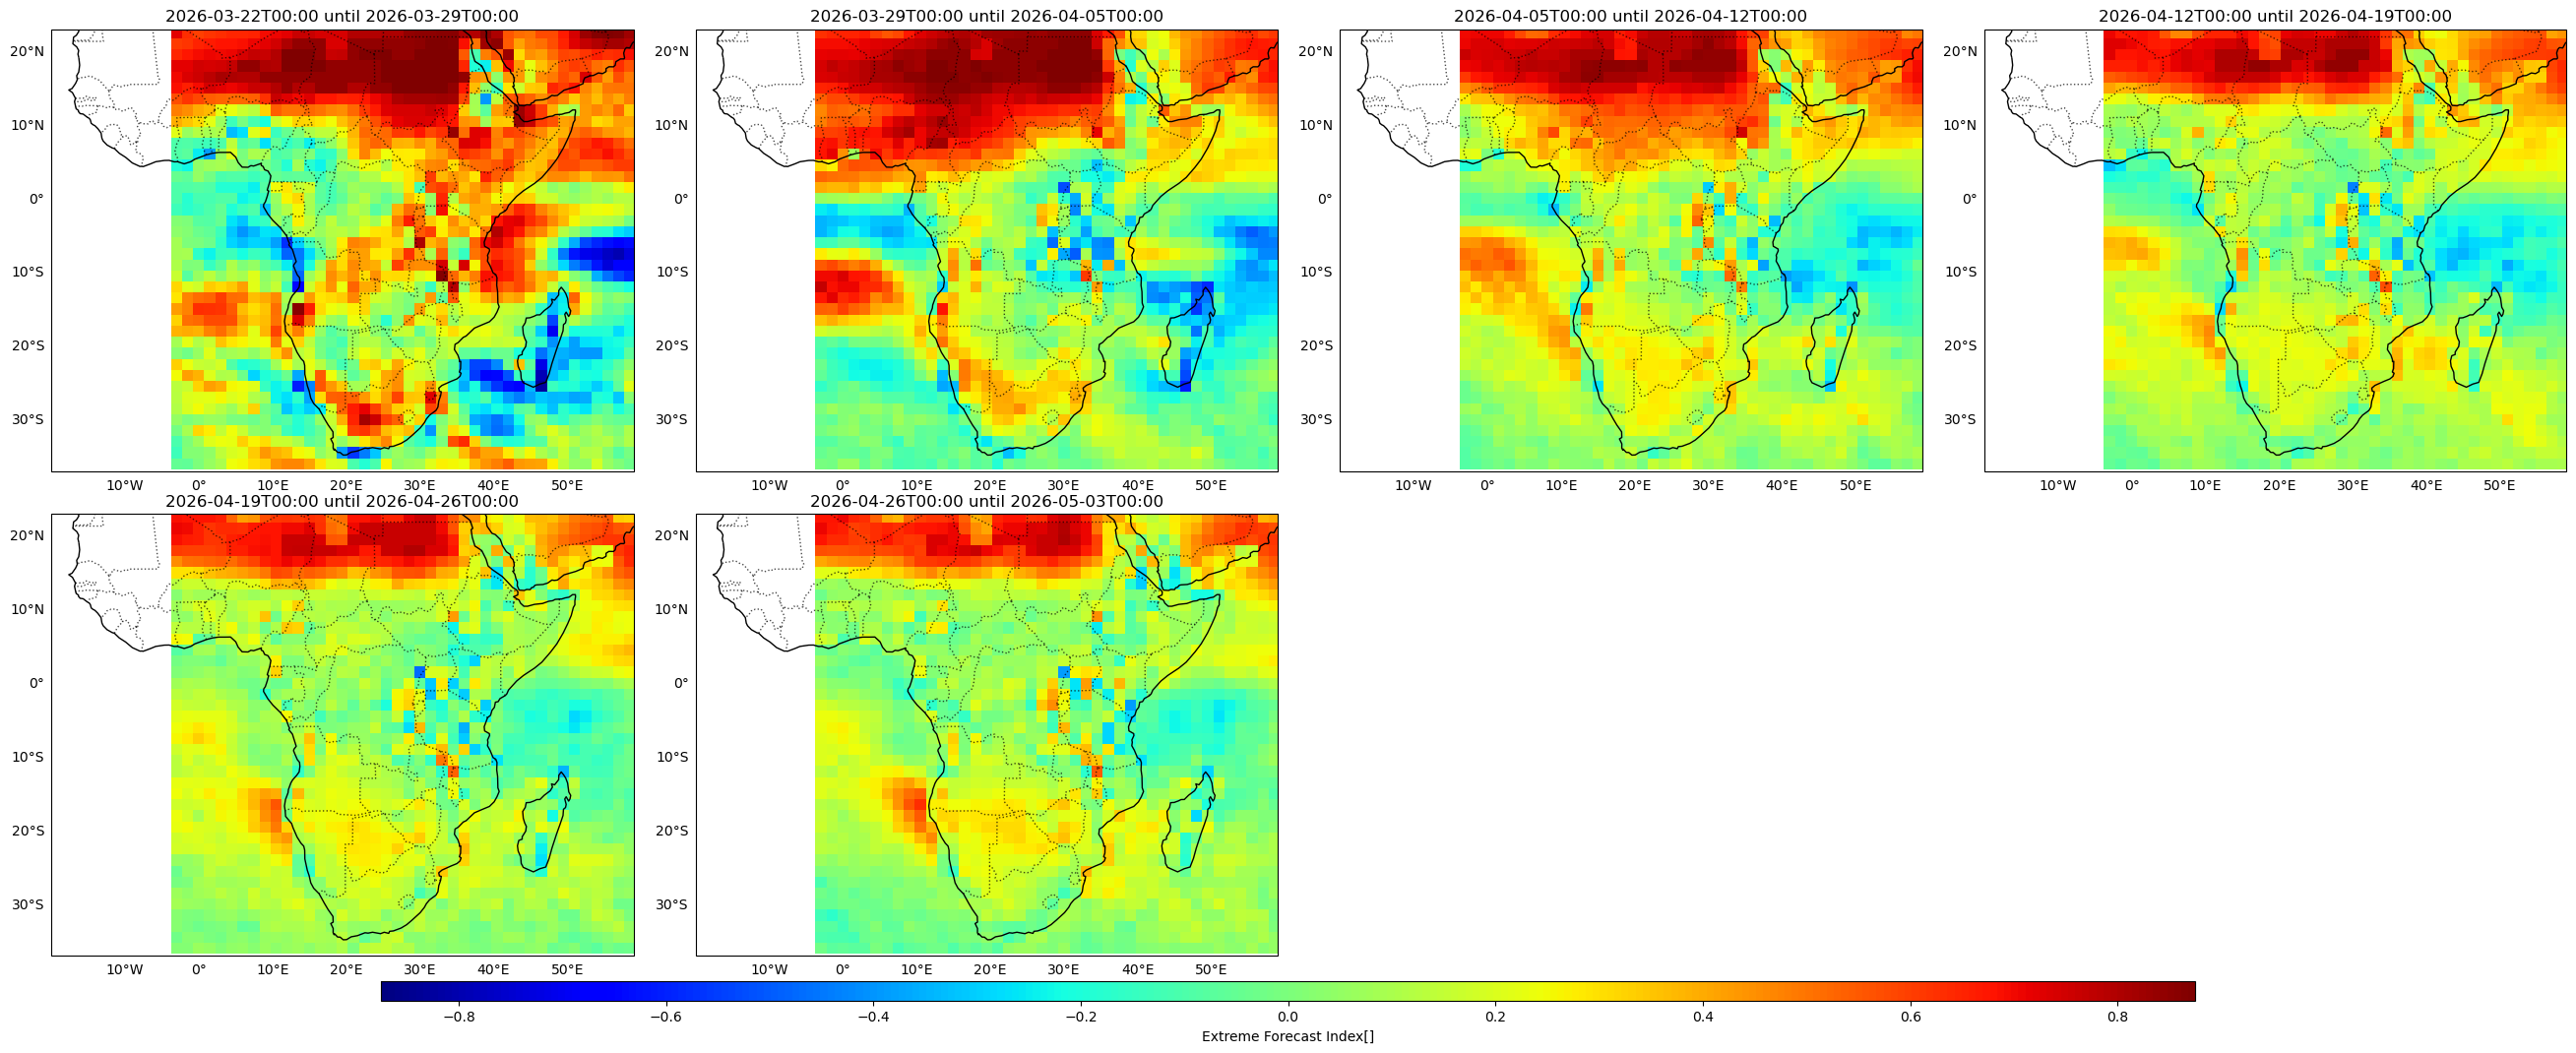

In [35]:
ds_to_plot=efi
fig=gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap='jet')

C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\matplotlib\colors.py:2294: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\matplotlib\colors.py:2294: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\matplotlib\colors.py:2294: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\matplotlib\colors.py:2294: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\matplotlib\colors.py:2294: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\matplotlib\colors.py:2294: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
C:\Users\alecj\Anaconda\envs

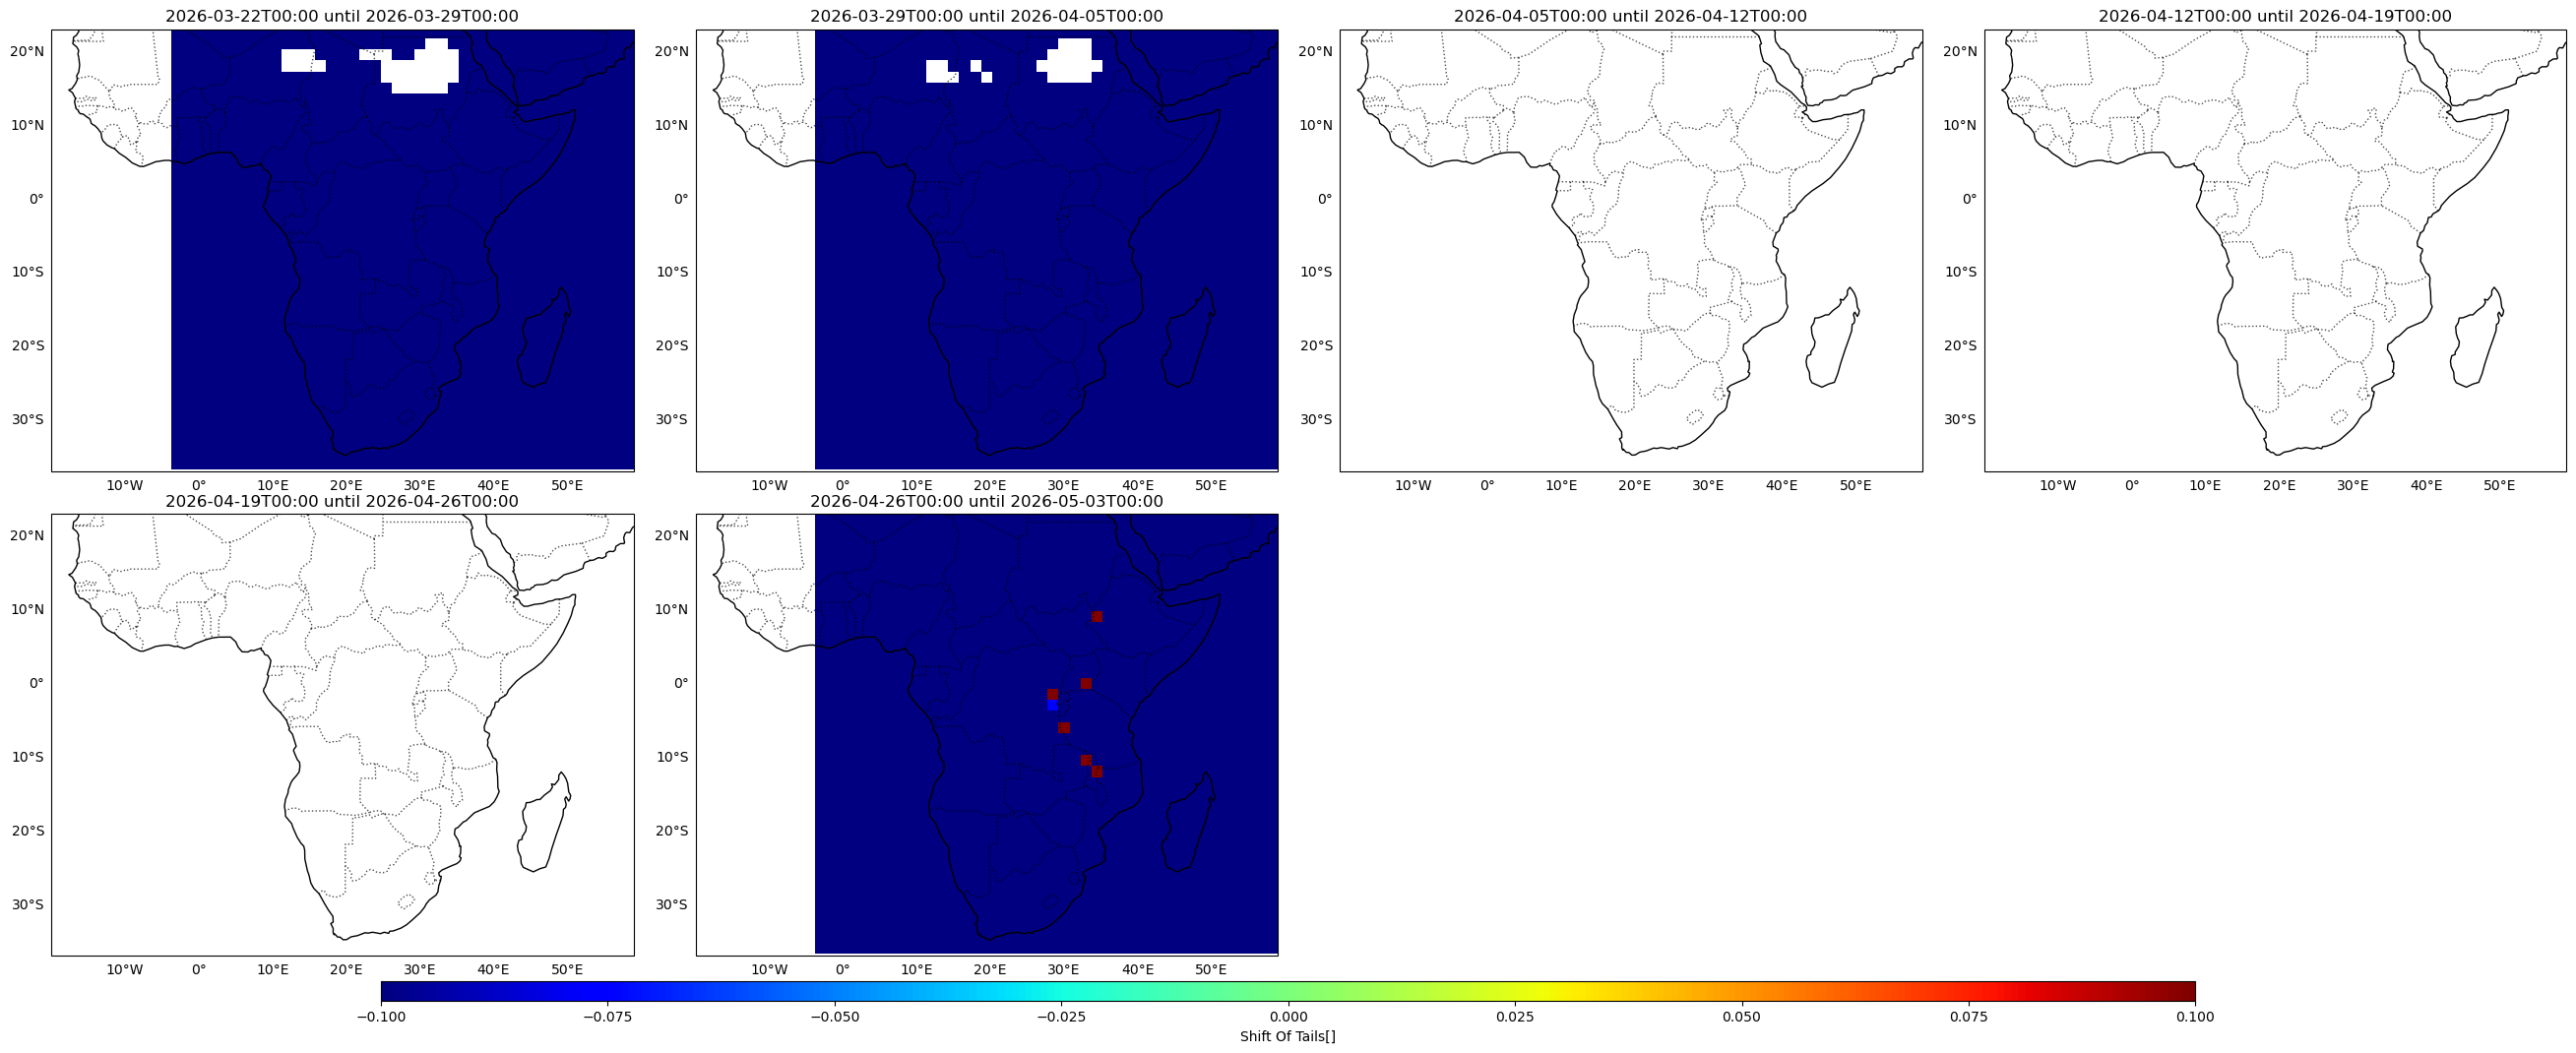

In [39]:
ds_to_plot=sot
fig=gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap='jet')

In [231]:
def EFI(data_f,data_clim_calc,ens_dim):
    data_mclim_quantiled = data_clim_calc.where(~data_clim_calc["quantile"].isin([0,1]),drop=True)#data_mclim.quantile(p,ens_dim)
    hold=[]    
    var='tp' 
    for i,forecast_timestep in enumerate(data_f.step.values):
        Qf = (data_f.isel(step=i) < data_mclim_quantiled.isel(time=i)).mean(ens_dim)
        result = 2/np.pi * ((quantile - Qf) / (quantile * (1-quantile))**.5).integrate("quantile")
        hold.append(result)
        
    EFI=xr.concat(hold,dim='step')
    EFI.attrs=data_f[var].attrs
    EFI.attrs['units']=''
    EFI.attrs['GRIB_name']='Extreme Forecast Index'
    EFI=EFI.assign_coords(time=data_f.time)
    return(EFI)

In [62]:
for step in range(len(efi["step"])):
    efi_sot.plot_map_EFI(efi.isel(step=step,time=0).drop_vars("time"),title="Extreme Forecast Index (EFI) for precipitation",
            cbar_title_upper="EFI for dry events", cbar_title_lower="EFI for wet events",)
    plt.savefig(f'{weekly_path}/EFI_step_{step}.png',bbox_inches='tight')

    #print(sot)
    efi_sot.plot_map_SOT(sot.isel(step=step,time=0))
    plt.title("Shift of tails (SOT) for precipitation")
    plt.savefig(f'{weekly_path}/SOT_step_{step}.png',bbox_inches='tight')

IndexError: index 0 is out of bounds for axis 3 with size 0

## plot with contour of another variable

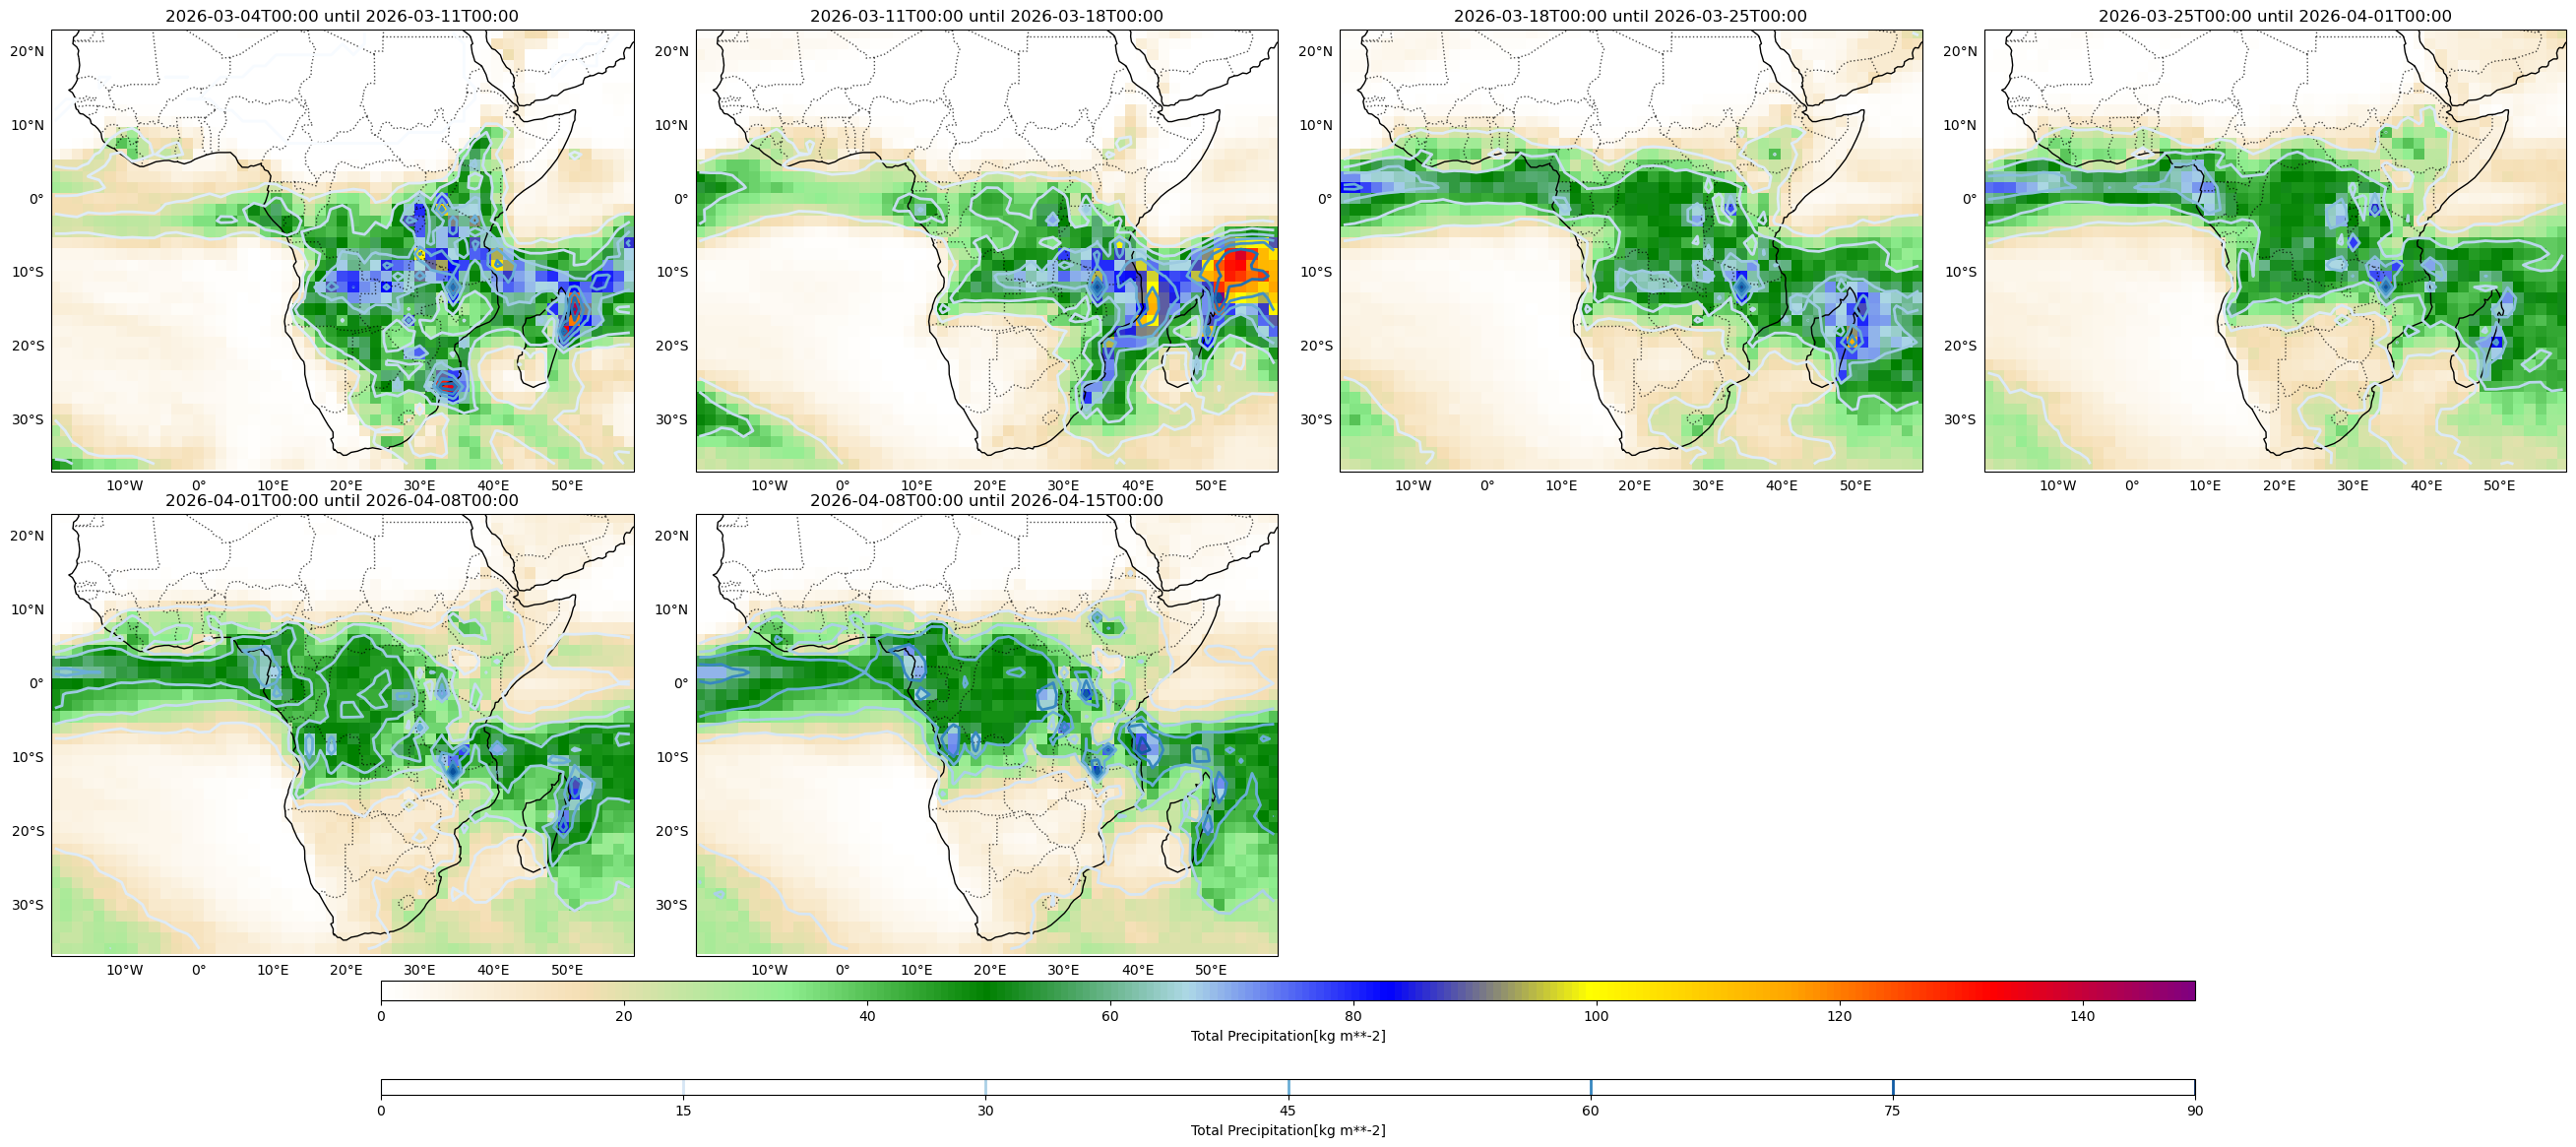

In [9]:
ds_to_plot=weekly_all_vars
fig=gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap=gef.cmap,add_contour=weekly_all_vars['tp'],contourcmap='Blues')

## plot the change in a variable

C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\get_ECMWF_functions.py:358: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_diff=xr.concat(ds_list,dim='step')


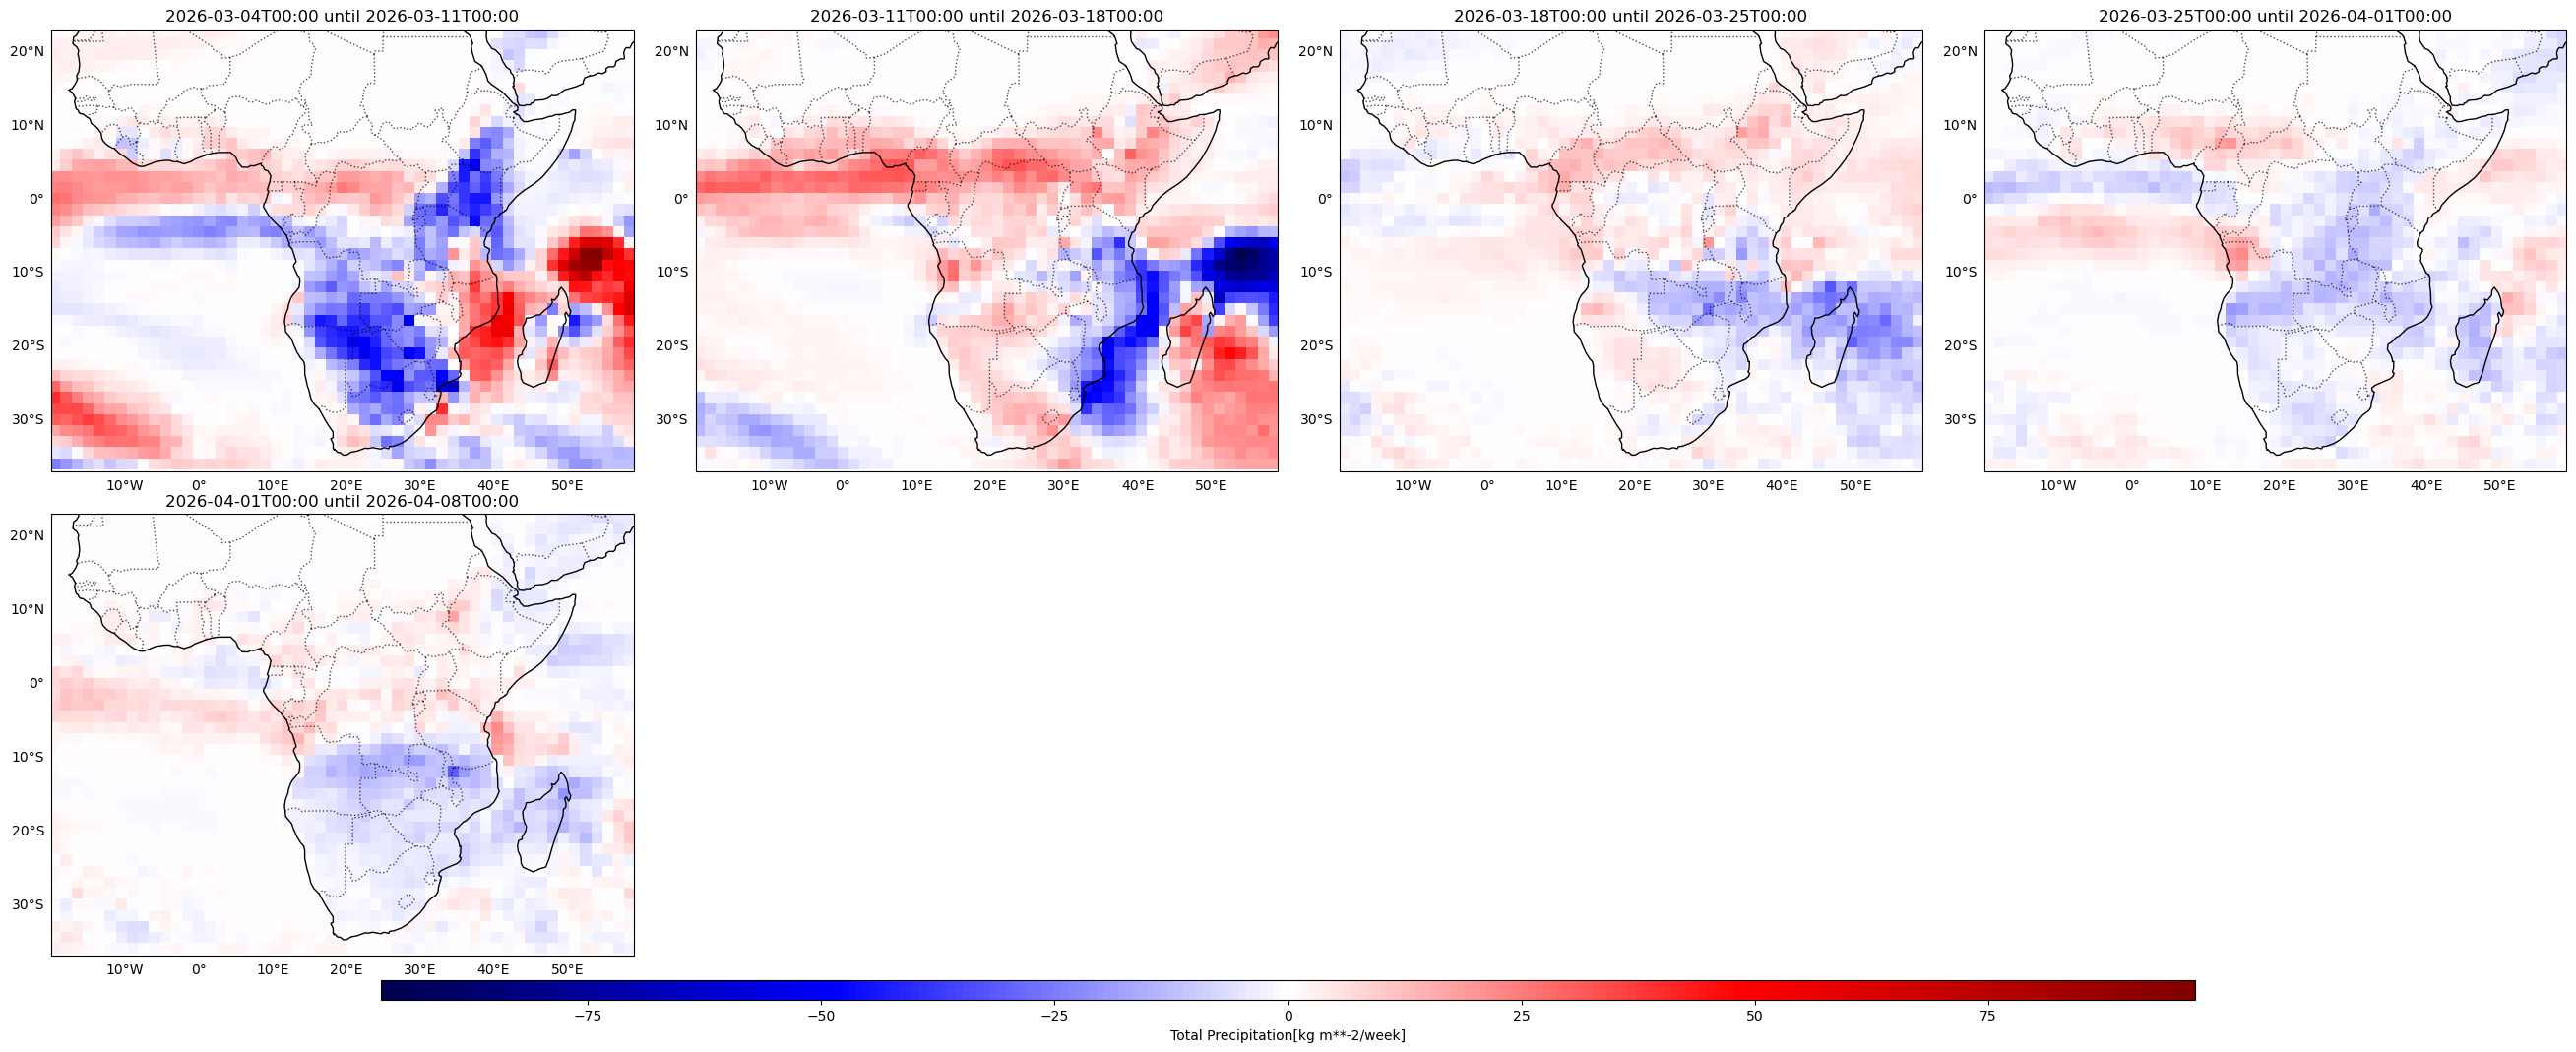

In [10]:
fontsize=16
ds_to_plot=weekly_all_vars
fig=gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap='seismic',change=True)

## Plot chance to exceed a certain condition

only works, if you download the ensemble members

possible conditions:

'greater', 'smaller', 'equal', 'not equal', 'greater or equal', 'smaller or equal'

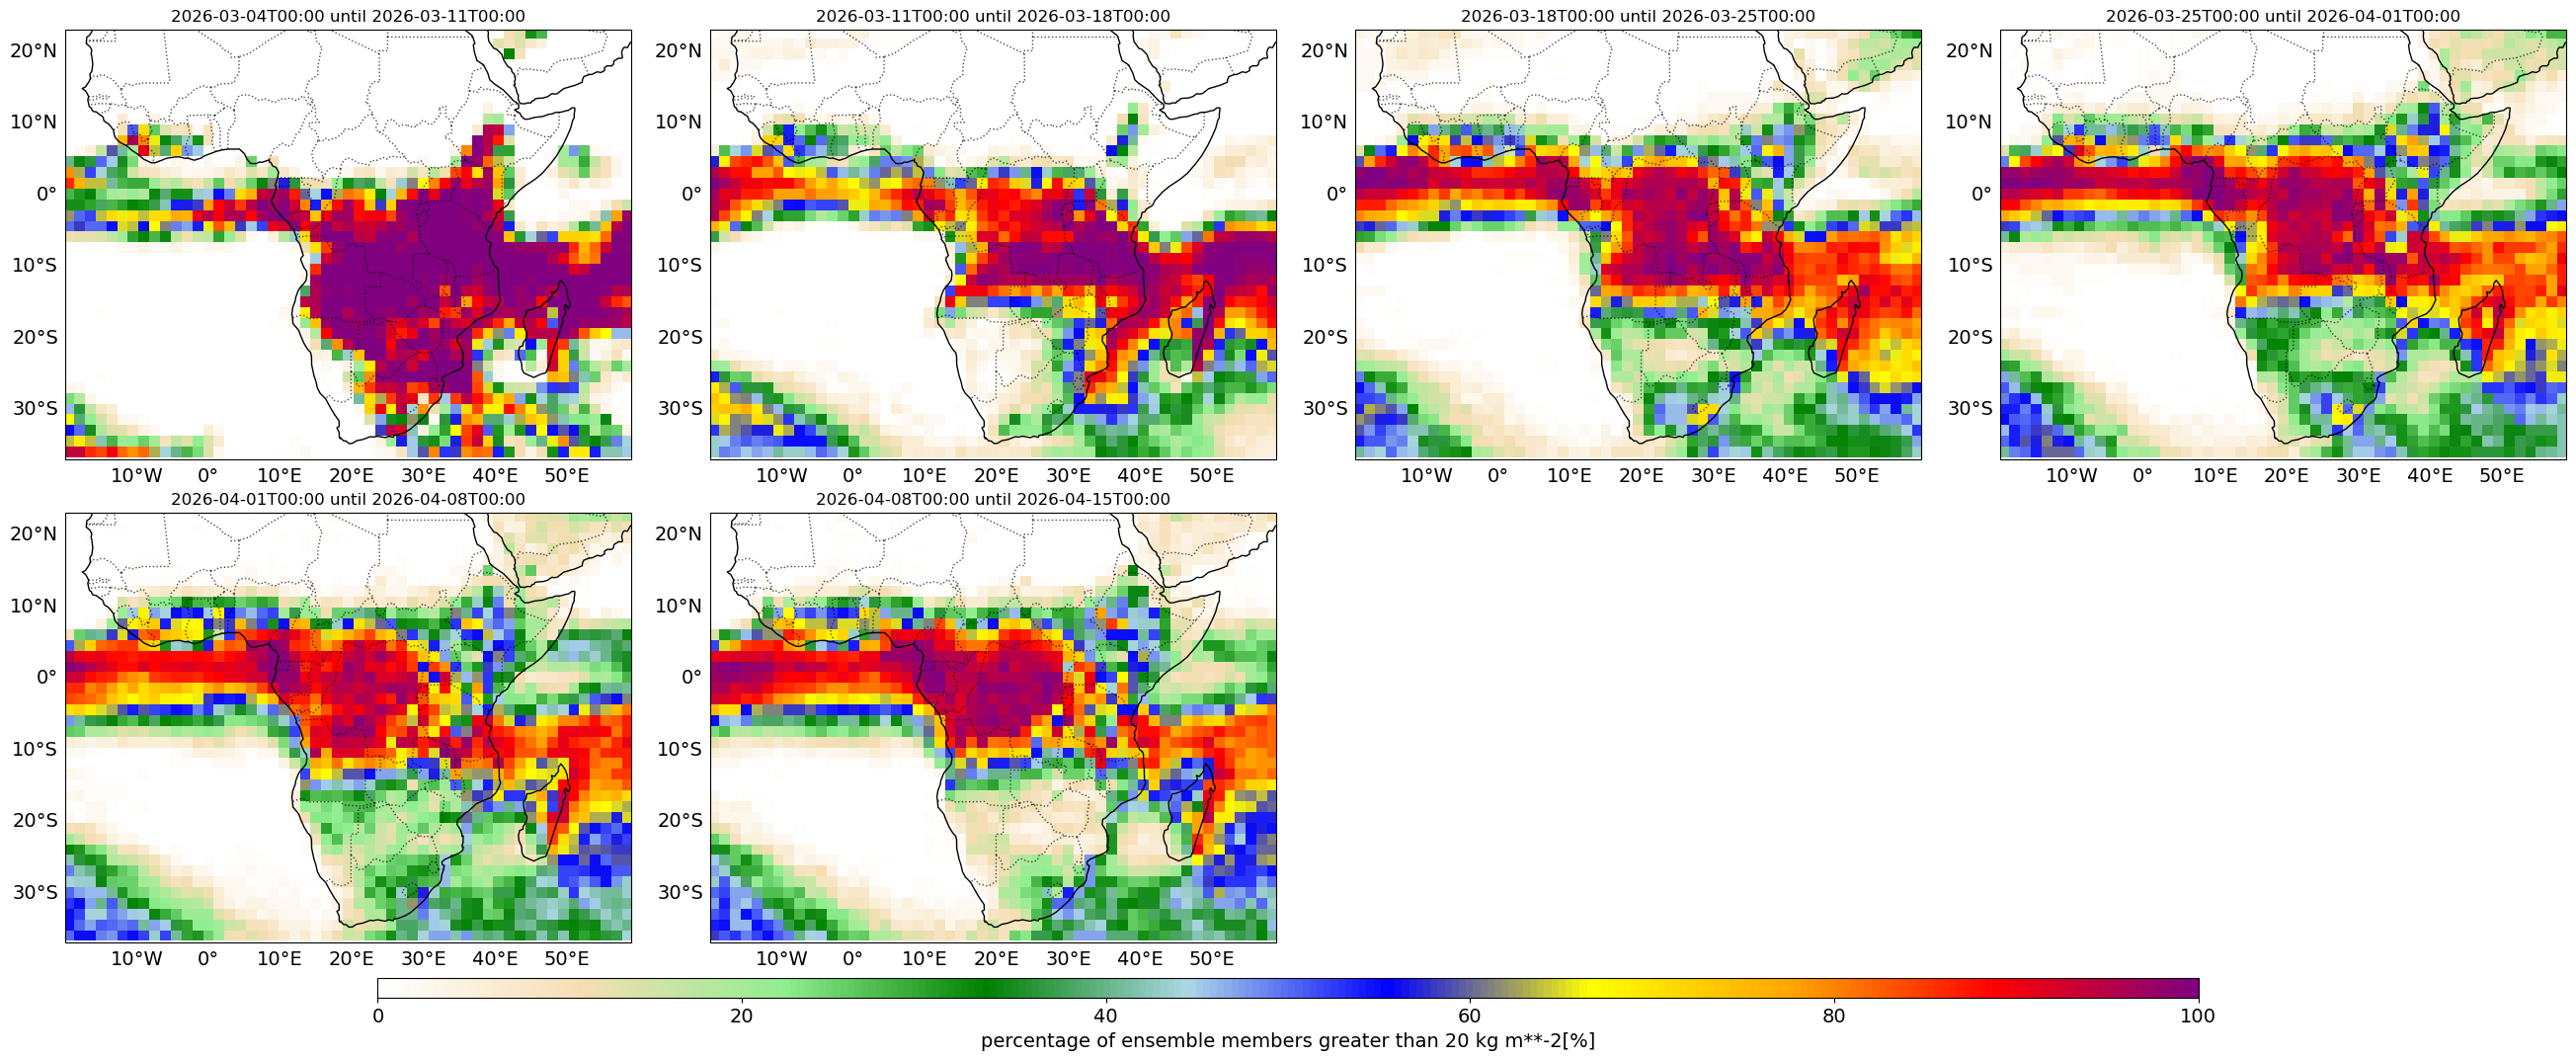

In [24]:
var='tp'
exceedance_percentage=gef.get_exceedance_percentage(weekly_all_vars,var,20,comparison='greater')
fig=gef.panel_plot_variable(exceedance_percentage,var,exceedance_percentage.step.values,cmap=gef.cmap)

## Spagetti plot

only works, if you download the ensemble members

In [ ]:
gef.spagetti_plot(daily_all_vars,'tp',lat=0,lon=30)

## Load the model climatology

In [146]:
### find the file that is closest in day to the starting day of the run
m_climate=gef.open_mclimate(daily_all_vars,folder_path=f'{str(Path.cwd().parent)}/m-climate/')

Model climatology starting on: 2025-03-21


## take a look at the model climatology

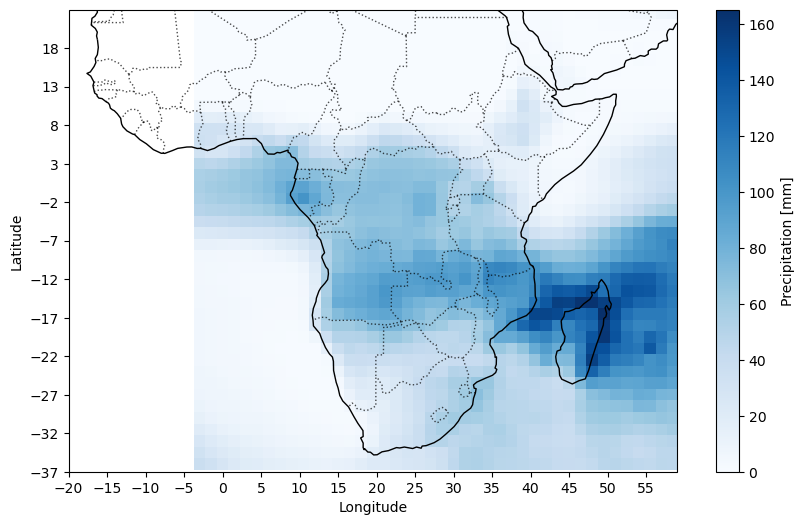

In [14]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
data=m_climate.isel(time=0).isel(quantile=90).sel(longitude=slice(lon1,lon2),latitude=slice(lat1,lat2))
cmap='Blues'
contour=ax.pcolormesh(data.longitude, data.latitude,data.tp, cmap=cmap)
ax.set_extent([lon1, lon2, lat2, lat1], crs=ccrs.PlateCarree())
# Add natural features for context (e.g., coastlines, borders)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':',alpha=0.7)
    
# Set tick marks for the longitude and latitude axes
ax.set_xticks(range(int(lon1), int(lon2), 5))  # Longitude ticks from 10 to 25
ax.set_yticks(range(int(lat2), int(lat1), 5))  # Latitude ticks from -30 to -15

# Add axis labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.colorbar(contour,label='Precipitation [mm]')

## Plot chance to exceed quantile of the model climatology

In [6]:
import xarray as xr
mclim=xr.open_dataset('yiping_cd_2025-11-11_on_target.nc')
mclimm=mclim.rename({'lon':'longitude','lat':'latitude'})

In [45]:
def chance_to_exceed_mclimate(ds,quantile,m_climate):
    if ds.longitude.values[2] not in m_climate.longitude.values:
        print('regridded')
        ds=ds.interp(latitude=m_climate.latitude, longitude=m_climate.longitude,method="linear")
    hold=[]    

    var='tp'
    for i,forecast_timestep in enumerate(ds.step.values):
        # date=ds.time+ds.sel(step=forecast_timestep).step.values-np.timedelta64(1, 'D')
        # start_time_2000s_date=datetime(2000, date.values.astype("M8[D]").astype(object).month, date.values.astype("M8[D]").astype(object).day)
        # new_time = m_climate.time.to_pandas() - pd.DateOffset(years=23)
        # m_climate = m_climate.assign_coords(time=new_time)
        m_climate_interp = m_climate.isel(time=i,quantile=quantile) #.sel(time=m_climate.sel(time=start_time_2000s_date,method='nearest').time)
        comparison = ds[var].sel(step=forecast_timestep)>m_climate_interp[var]#.sel(time=ds[var].sel(step=forecast_timestep).valid_time.values, method="nearest")
        chance=comparison.sum(dim='number')/ ds.sizes['number']*100
        hold.append(chance)    

    chance_to_exceed = xr.concat(hold,dim="step")
    chance_to_exceed.attrs=ds[var].attrs
    chance_to_exceed.attrs['units']='%'
    chance_to_exceed.attrs['GRIB_name']='chance to exceed climatology'
    chance_to_exceed=chance_to_exceed.to_dataset()
    chance_to_exceed=chance_to_exceed.assign_coords(time=ds.time)
    return(chance_to_exceed)

chance_to_exceed=chance_to_exceed_mclimate(weekly_all_vars,quantile=75,m_climate=m_climate)

C:\Users\alecj\AppData\Local\Temp\ipykernel_14032\2185656625.py:18: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  chance_to_exceed = xr.concat(hold,dim="step")


C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\get_ECMWF_functions.py:1069: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  chance_to_exceed=xr.concat(hold,dim='step')


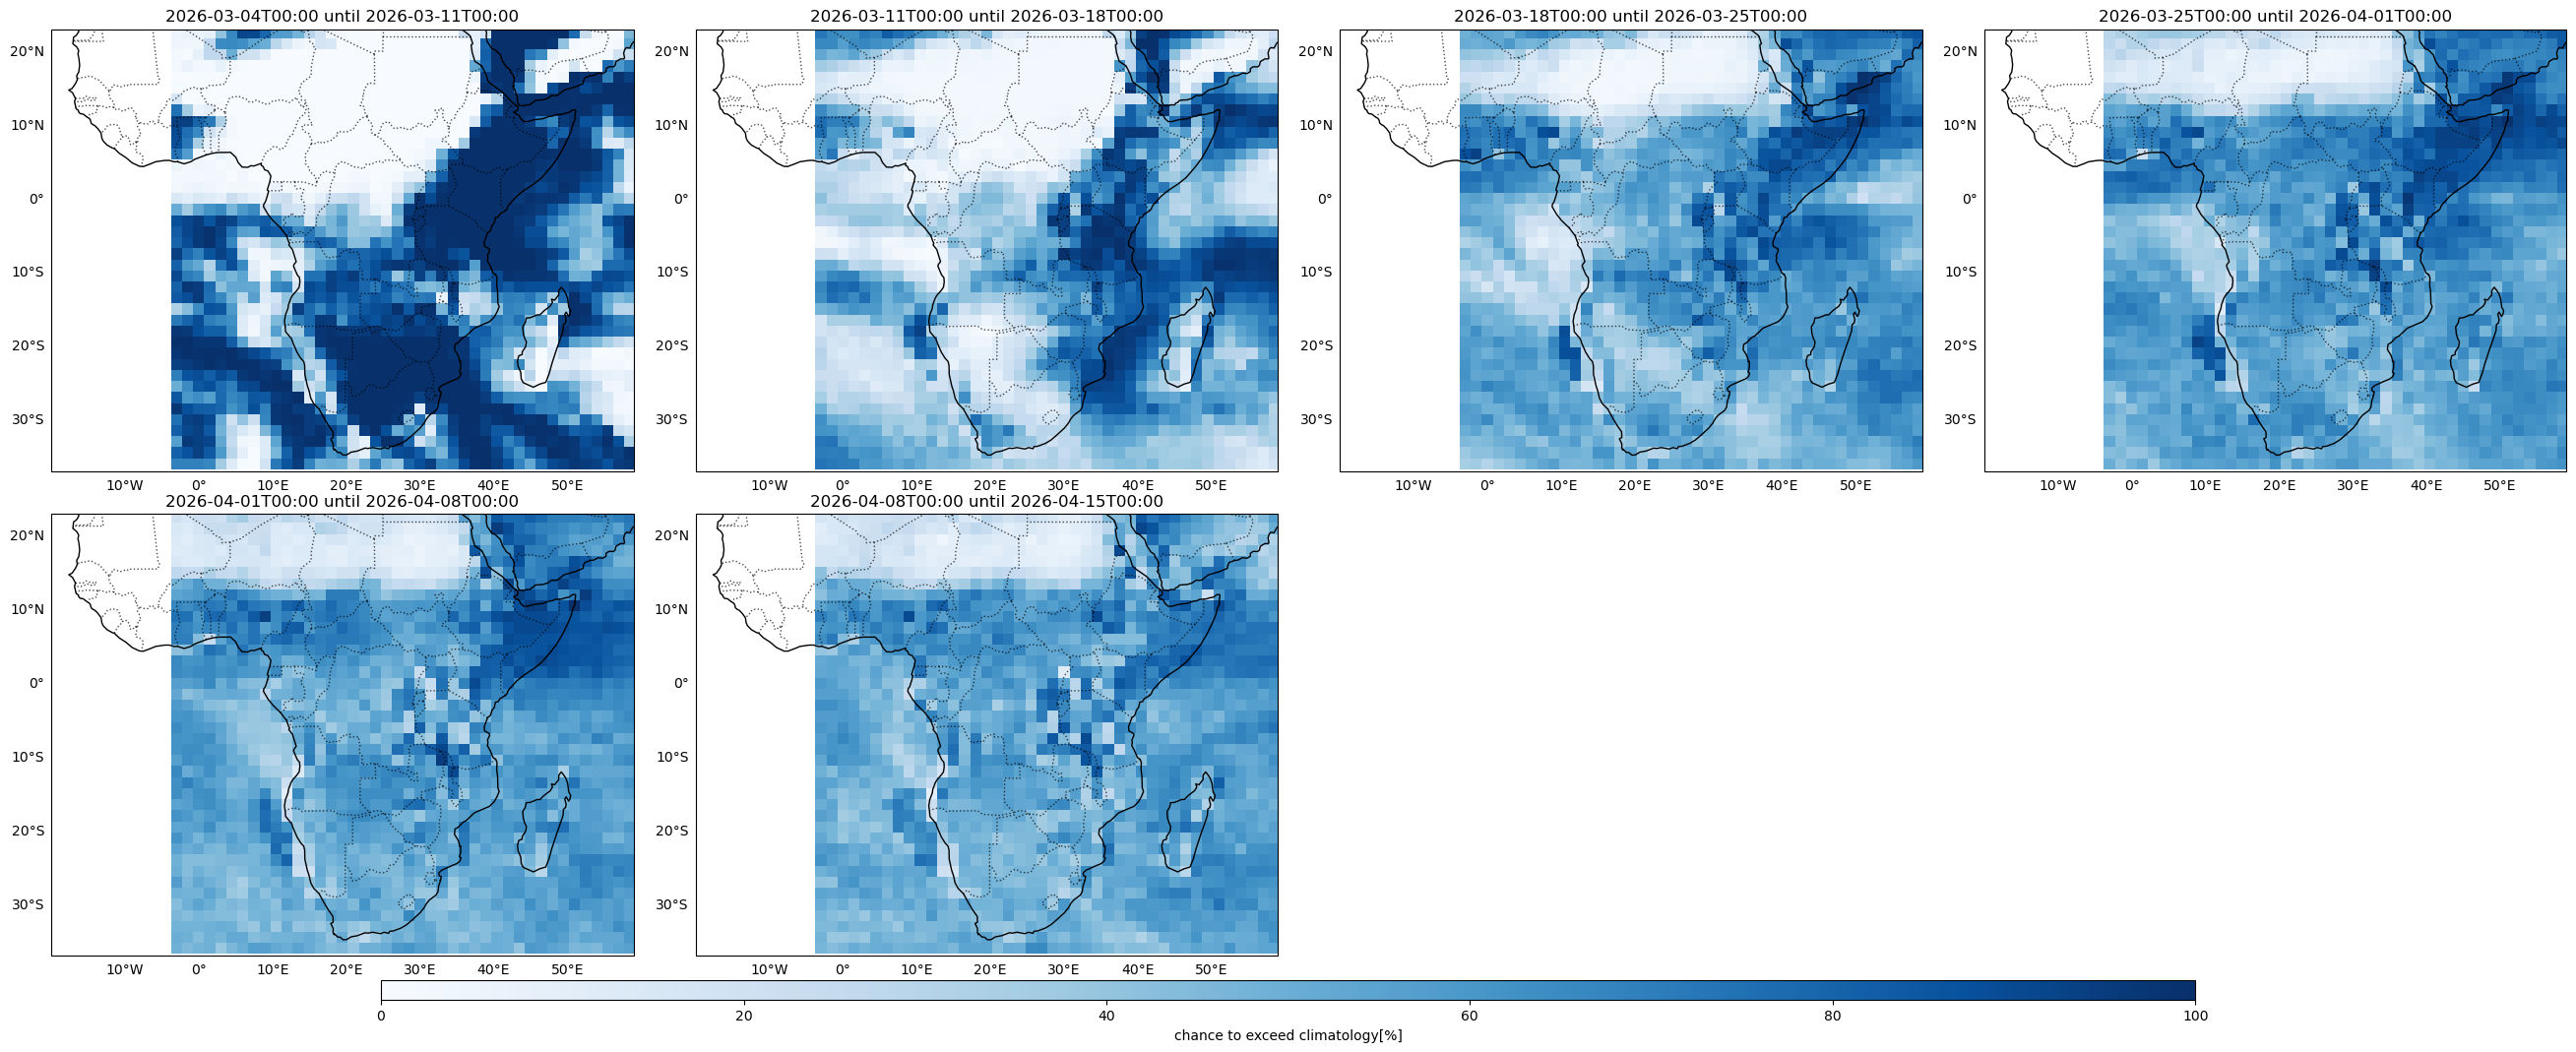

In [15]:
chance_to_exceed=gef.chance_to_exceed_mclimate(weekly_all_vars,quantile=50,m_climate=m_climate)
fig=gef.panel_plot_variable(chance_to_exceed,'tp',chance_to_exceed.step.values,cmap='Blues',fontsize=16)

## Plot anomaly of the ensemble mean from quantile of the model climatology

C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\get_ECMWF_functions.py:1086: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  anom_clim=xr.concat(hold,dim='step')


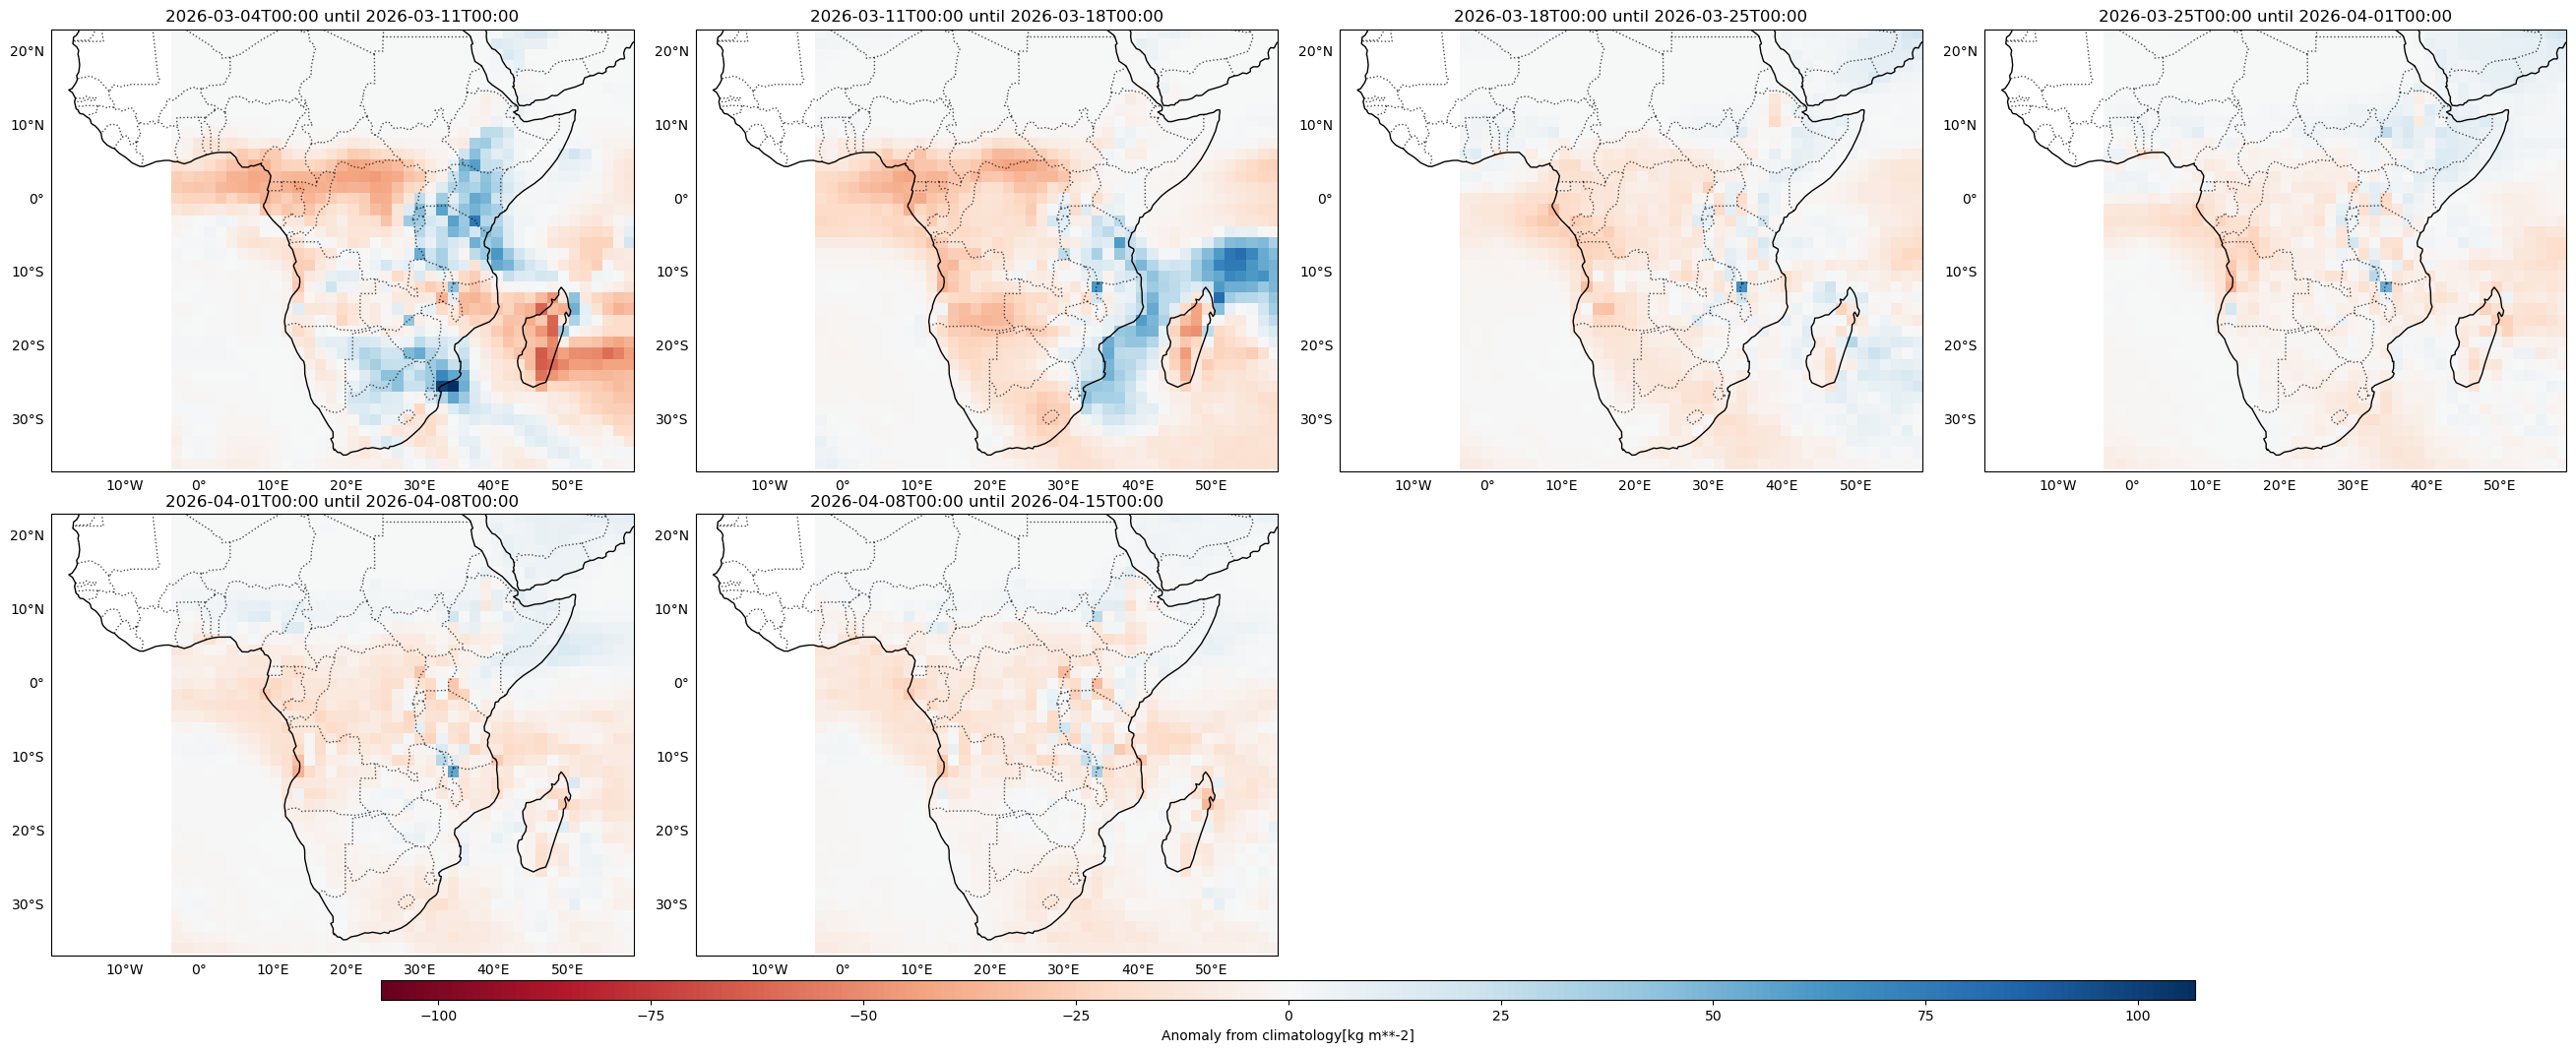

In [16]:
anom_clim=gef.anomaly_from_mclimate(weekly_all_vars,quantile=75,m_climate=m_climate)
fig=gef.panel_plot_variable(anom_clim,'tp',anom_clim.step.values,cmap='RdBu',fontsize=16)

## Plot chance of forecast being in a tercile catagory of the model climatology

C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\get_ECMWF_functions.py:1123: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  tercile_clim=xr.concat(hold,dim='step')


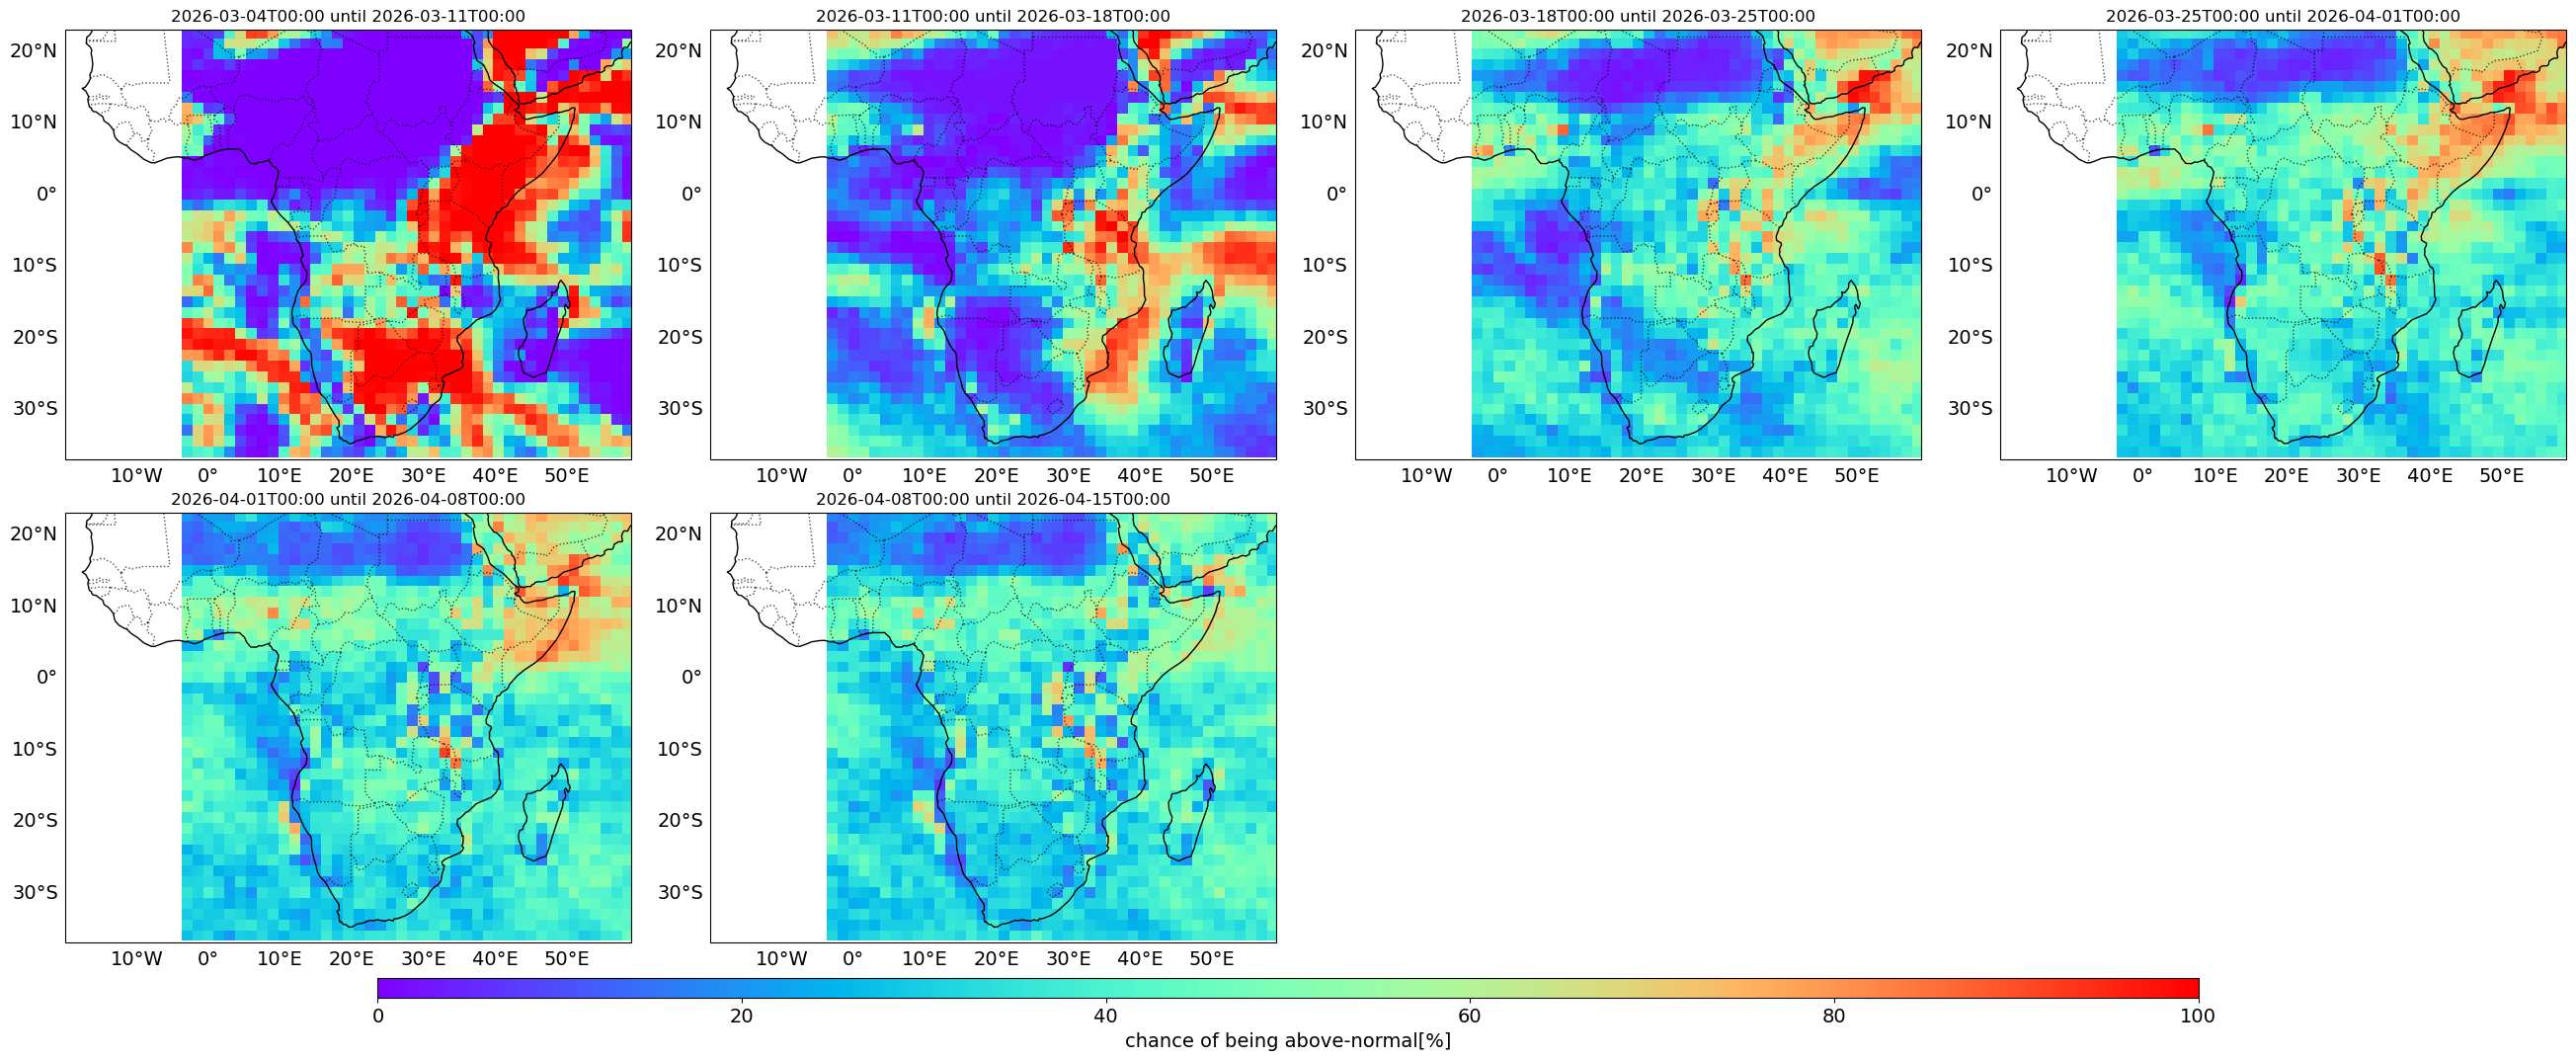

In [21]:
fontsize=14
plt.rcParams.update({'font.size': fontsize})
tercile_clim=gef.tercile_from_mclimate(weekly_all_vars,'tp',category_choice='above-normal',m_climate=m_climate)
fig=gef.panel_plot_variable(tercile_clim,'tp',tercile_clim.step.values,cmap='rainbow')

# Meteogram 
boxes show the min,10th,25th,median,75th,90th & max for the data.

shading shows from 10th to 25h, 25th to 75th & 75th to 90th of the climatology, gray line in middle of shading is the median 


<Axes: title={'center': 'Meteogram: Box-and-Whisker Plot compared to climatology for lat: -1.5 lon: 36.0'}, xlabel='Forecast Time Step', ylabel='Precipitation (mm/day)'>

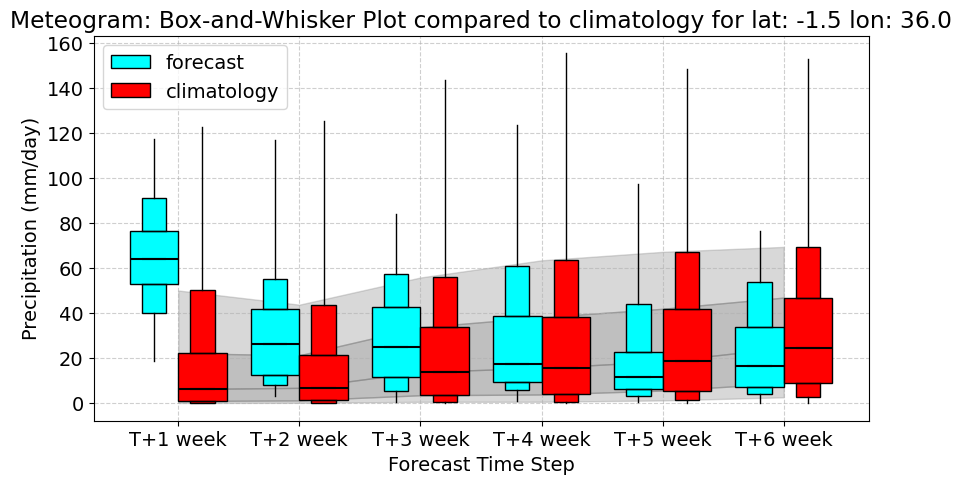

In [22]:
gef.meteogram_double(weekly_all_vars,m_climate,lat=-1,lon=36)

### Plot a windrose for a gridbox

make a windrose for each week for a certain lat lon combination, or select a city like shown below

In [ ]:
lat=-22
lon=13
gef.make_windroses(ds_hourly,lat,lon,10,len(np.atleast_1d(weekly_all_vars.step.values)))

In [23]:
import os
import re

folder_path = "C:\\Users\\alecj\\Bureaublad\\ECMWF-S2S4AFRICA\\m-climate\\"

for filename in os.listdir(folder_path):
    if filename.endswith(".nc") and "yiping_cd" in filename:
        new_name = filename.replace("yiping_cd", "m-climate")
        os.rename(
            os.path.join(folder_path, filename),
            os.path.join(folder_path, new_name)
        )
        print(f"Renamed: {filename} → {new_name}")

Renamed: yiping_cd_2024-11-17.nc → m-climate_2024-11-17.nc
Renamed: yiping_cd_2024-11-19.nc → m-climate_2024-11-19.nc
Renamed: yiping_cd_2024-11-21.nc → m-climate_2024-11-21.nc
Renamed: yiping_cd_2024-11-23.nc → m-climate_2024-11-23.nc
Renamed: yiping_cd_2024-11-25.nc → m-climate_2024-11-25.nc
Renamed: yiping_cd_2024-11-27.nc → m-climate_2024-11-27.nc
Renamed: yiping_cd_2024-11-29.nc → m-climate_2024-11-29.nc
Renamed: yiping_cd_2024-12-01.nc → m-climate_2024-12-01.nc
Renamed: yiping_cd_2024-12-03.nc → m-climate_2024-12-03.nc
Renamed: yiping_cd_2024-12-05.nc → m-climate_2024-12-05.nc
Renamed: yiping_cd_2024-12-07.nc → m-climate_2024-12-07.nc
Renamed: yiping_cd_2024-12-09.nc → m-climate_2024-12-09.nc
Renamed: yiping_cd_2024-12-11.nc → m-climate_2024-12-11.nc
Renamed: yiping_cd_2024-12-13.nc → m-climate_2024-12-13.nc
Renamed: yiping_cd_2024-12-15.nc → m-climate_2024-12-15.nc
Renamed: yiping_cd_2024-12-17.nc → m-climate_2024-12-17.nc
Renamed: yiping_cd_2024-12-19.nc → m-climate_2024-12-19.